In [ ]:
import pandas as pd
import numpy as np
import re  
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import OneHotEncoder
import optuna
import sklearn
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sklearn.set_config(transform_output="default")

In [ ]:
def get_bureau_features(path='/kaggle/input/competitions/home-credit-default-risk/bureau.csv'):
    bureau = pd.read_csv(path)
    
    bureau_agg = bureau.groupby('SK_ID_CURR').agg({
        'DAYS_CREDIT': ['mean', 'max', 'min'],
        'DAYS_CREDIT_ENDDATE': ['mean'],
        'AMT_CREDIT_SUM': ['mean', 'sum'],
        'AMT_CREDIT_SUM_DEBT': ['mean', 'sum'],
        'AMT_CREDIT_MAX_OVERDUE': ['mean'],
        'CNT_CREDIT_PROLONG': ['sum'],
    })
    
    bureau_agg.columns = pd.Index(['BUREAU_' + e[0] + "_" + e[1].upper() for e in bureau_agg.columns.tolist()])
    
    bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = (bureau_agg['BUREAU_AMT_CREDIT_SUM_DEBT_SUM'] / 
                                              (bureau_agg['BUREAU_AMT_CREDIT_SUM_SUM'] + 1e-6))
    
    bureau_agg['BUREAU_LOAN_COUNT'] = bureau.groupby('SK_ID_CURR').size()
    
    return bureau_agg.reset_index()

def get_prev_apps_features(path='/kaggle/input/competitions/home-credit-default-risk/previous_application.csv'):
    prev = pd.read_csv(path)
    
    prev_agg = prev.groupby('SK_ID_CURR').agg({
        'AMT_ANNUITY': ['mean', 'max'],
        'AMT_APPLICATION': ['mean', 'max'],
        'AMT_CREDIT': ['mean', 'max'],
        'AMT_DOWN_PAYMENT': ['mean', 'max'],
        'DAYS_DECISION': ['mean', 'max'],
        'CNT_PAYMENT': ['mean', 'sum'],
    })
    prev_agg.columns = pd.Index(['PREV_' + e[0] + "_" + e[1].upper() for e in prev_agg.columns.tolist()])
    
    prev_agg['PREV_APPROVED_COUNT'] = prev[prev['NAME_CONTRACT_STATUS'] == 'Approved'].groupby('SK_ID_CURR').size()
    prev_agg['PREV_REFUSED_COUNT'] = prev[prev['NAME_CONTRACT_STATUS'] == 'Refused'].groupby('SK_ID_CURR').size()
    prev_agg = prev_agg.fillna(0)
    
    return prev_agg.reset_index()

def get_installments_features(path='/kaggle/input/competitions/home-credit-default-risk/installments_payments.csv'):
    ins = pd.read_csv(path)
    
    ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
    
    ins['DPD'] = ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']
    ins['DPD'] = ins['DPD'].apply(lambda x: x if x > 0 else 0) # Days Past Due
    
    ins_agg = ins.groupby('SK_ID_CURR').agg({
        'PAYMENT_DIFF': ['mean', 'max', 'sum'],
        'DPD': ['mean', 'max', 'sum'],
        'AMT_PAYMENT': ['mean', 'sum'],
        'DAYS_ENTRY_PAYMENT': ['max', 'mean']
    })
    ins_agg.columns = pd.Index(['INS_' + e[0] + "_" + e[1].upper() for e in ins_agg.columns.tolist()])
    
    return ins_agg.reset_index()

print("🛠️ Extracting features from other tables...")
bureau_df = get_bureau_features()
prev_df = get_prev_apps_features()
ins_df = get_installments_features()


def merge_all(main_df, bureau_df, prev_df, ins_df):
    main_df = main_df.merge(bureau_df, on='SK_ID_CURR', how='left')
    main_df = main_df.merge(prev_df, on='SK_ID_CURR', how='left')
    main_df = main_df.merge(ins_df, on='SK_ID_CURR', how='left')
    return main_df

print("🔗 Merging all tables...")
path = '/kaggle/input/competitions/home-credit-default-risk/'

df_sample = pd.read_csv(path + 'application_train.csv')
test_full = pd.read_csv(path + 'application_test.csv')

df_sample = merge_all(df_sample, bureau_df, prev_df, ins_df)
test_full = merge_all(test_full, bureau_df, prev_df, ins_df)

X_train = df_sample.drop(columns=['TARGET', 'SK_ID_CURR'])
y_train = df_sample['TARGET']

X_test = test_full[X_train.columns]

numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"✅ Done! New feature count: {X_train.shape[1]}")

🛠️ Extracting features from other tables...
🔗 Merging all tables...
✅ Done! New feature count: 156


In [ ]:
print("💾 Saving final datasets to disk...")
df_sample.to_csv('final_full_dataset.csv', index=False)
test_full.to_csv('final_test_dataset.csv', index=False)
print(f"📁 Files saved: 'final_full_dataset.csv' ({df_sample.shape}) and 'final_test_dataset.csv' ({test_full.shape})")

💾 Saving final datasets to disk...
📁 Files saved: 'final_full_dataset.csv' ((307511, 158)) and 'final_test_dataset.csv' ((48744, 157))


In [5]:
df_sample = pd.read_csv("/kaggle/working/final_full_dataset.csv", low_memory=False)
df_sample.head(5)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_DPD_MEAN,INS_DPD_MAX,INS_DPD_SUM,INS_AMT_PAYMENT_MEAN,INS_AMT_PAYMENT_SUM,INS_DAYS_ENTRY_PAYMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MEAN
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0.000000,0.000,0.000,0.000000,0.0,0.0,11559.247105,219625.695,-49.0,-315.421053
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0.000000,0.000,0.000,0.000000,0.0,0.0,64754.586000,1618864.650,-544.0,-1385.320000
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0.000000,0.000,0.000,0.000000,0.0,0.0,7096.155000,21288.465,-727.0,-761.666667
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.000000,0.000,0.000,0.000000,0.0,0.0,62947.088438,1007153.415,-12.0,-271.625000
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,452.384318,22655.655,29857.365,0.954545,12.0,63.0,12214.060227,806127.975,-14.0,-1032.242424


In [6]:
print("Shape of data : ", df_sample.shape)
print("targrt destribution : ", df_sample['TARGET'].value_counts(normalize=True))
missing = df_sample.isnull().sum() / len(df_sample)
print("Columns that have more than 50% of it's value = null", missing[missing > 0.5]) 

Shape of data :  (307511, 158)
targrt destribution :  TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Columns that have more than 50% of it's value = null OWN_CAR_AGE                 0.659908
EXT_SOURCE_1                0.563811
APARTMENTS_AVG              0.507497
BASEMENTAREA_AVG            0.585160
YEARS_BUILD_AVG             0.664978
COMMONAREA_AVG              0.698723
ELEVATORS_AVG               0.532960
ENTRANCES_AVG               0.503488
FLOORSMIN_AVG               0.678486
LANDAREA_AVG                0.593767
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAREA_AVG              0.501933
NONLIVINGAPARTMENTS_AVG     0.694330
NONLIVINGAREA_AVG           0.551792
APARTMENTS_MODE             0.507497
BASEMENTAREA_MODE           0.585160
YEARS_BUILD_MODE            0.664978
COMMONAREA_MODE             0.698723
ELEVATORS_MODE              0.532960
ENTRANCES_MODE              0.503488
FLOORSMIN_MODE              0.678486
LANDAREA_MODE               0.593767
LIVINGAPART

In [7]:
X_train = df_sample.drop(columns=['TARGET', 'SK_ID_CURR']) 
y_train = df_sample['TARGET']

test_full = pd.read_csv("/kaggle/working/final_test_dataset.csv")
test_ids = test_full['SK_ID_CURR']
X_test = test_full[X_train.columns] 

In [ ]:
def apply_feature_engineering(df):
    df['ANNUITY_INCOME_PERC'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
    df['PAYMENT_RATE'] = df['AMT_ANNUITY'] / df['AMT_CREDIT']
    df['INCOME_CREDIT_PERC'] = df['AMT_INCOME_TOTAL'] / df['AMT_CREDIT']
    df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
    df['DAYS_EMPLOYED_PERC'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['EXT_SOURCES_PROD'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']
    df['EXT_SOURCES_STD'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].std(axis=1)
    df['EXT_SOURCES_STD'] = df['EXT_SOURCES_STD'].fillna(df['EXT_SOURCES_STD'].mean())
    df['CREDIT_ANNUITY_RATIO'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
    df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
    df['INCOME_ANNUITY_CHUNKS'] = df['AMT_INCOME_TOTAL'] / df['AMT_ANNUITY']
    df['CREDIT_DOWNPAYMENT'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']
    df['EMPLOYED_AGE_RATIO'] = df['DAYS_EMPLOYED'] / df['DAYS_BIRTH']
    df['AGE_INT'] = (df['DAYS_BIRTH'] / -365).astype(int)    
    df['EXT_SOURCE_1_OVER_3'] = df['EXT_SOURCE_1'] / (df['EXT_SOURCE_3'] + 1e-6)
    df['EXT_SOURCE_2_OVER_3'] = df['EXT_SOURCE_2'] / (df['EXT_SOURCE_3'] + 1e-6)
    df['EXT_SOURCES_SUM'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].sum(axis=1)
    df['EXT_SOURCES_MEAN'] = df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
    df['REGION_ID_POP_CAT'] = df['REGION_POPULATION_RELATIVE'].astype('category')
    return df

X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

In [9]:
numeric_cols = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler()) 
])

In [ ]:
XGB_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown', add_indicator=True)),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,     
        min_frequency=0.01       
    ))
])

XGB_preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_cols),
    ('cat', XGB_cat_pipeline, categorical_cols)
])

def xgb_objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 8, 12),
        'n_estimators': 1000, 
        'tree_method': 'hist',
        'device': 'cuda',
        'random_state': 42,
        'early_stopping_rounds': 50
    }
    
    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for t_idx, v_idx in skf_opt.split(X_train, y_train):
        xt, xv = X_train.iloc[t_idx], X_train.iloc[v_idx]
        yt, yv = y_train.iloc[t_idx], y_train.iloc[v_idx]
        
        xt_p = XGB_preprocessor.fit_transform(xt)
        xv_p = XGB_preprocessor.transform(xv)
        
        model = xgb.XGBClassifier(**params)
        model.fit(xt_p, yt, eval_set=[(xv_p, yv)], verbose=False)
        preds = model.predict_proba(xv_p)[:, 1]
        scores.append(roc_auc_score(yv, preds))
    return np.mean(scores)

XGB_study = optuna.create_study(direction='maximize')
XGB_study.optimize(xgb_objective, n_trials=10) 
print("XGB best params : ", XGB_study.best_params)

XGB_final_params = {
    **XGB_study.best_params,
    'n_estimators': 2000, 
    'tree_method': 'hist',
    'device': 'cuda',
    'random_state': 42,
    'eval_metric': 'auc',
    'early_stopping_rounds': 50
}

XGB_full_pipeline = Pipeline(steps=[
    ('preprocessor', XGB_preprocessor),
    ('classifier', xgb.XGBClassifier(**XGB_final_params))
])

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
XGB_oof_preds = np.zeros(len(X_train))
XGB_test_preds_total = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"started Fold {fold + 1}")
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    XGB_preprocessor.fit(X_fold_train, y_fold_train)
    X_val_transformed = XGB_preprocessor.transform(X_fold_val)
    
    XGB_full_pipeline.fit(
        X_fold_train, y_fold_train,
        classifier__eval_set=[(X_val_transformed, y_fold_val)],
        classifier__verbose=False 
    )
    
    XGB_oof_preds[val_idx] = XGB_full_pipeline.predict_proba(X_fold_val)[:, 1]
    XGB_test_preds_total += XGB_full_pipeline.predict_proba(X_test)[:, 1] / n_splits
    print(f"✅ Fold {fold + 1} Done!")

print(f"XGB Overall AUC: {roc_auc_score(y_train, XGB_oof_preds):.5f}")

[I 2026-04-29 20:20:33,061] A new study created in memory with name: no-name-dc5b31a8-8740-4a47-8ee6-94ead7b0b1ce
[I 2026-04-29 20:21:51,017] Trial 0 finished with value: 0.7774405178120851 and parameters: {'learning_rate': 0.03948821587267717, 'max_depth': 6, 'min_child_weight': 3, 'subsample': 0.6042323427314769, 'colsample_bytree': 0.7775004330377635, 'scale_pos_weight': 8.618082583737863}. Best is trial 0 with value: 0.7774405178120851.
[I 2026-04-29 20:23:07,230] Trial 1 finished with value: 0.7724695947115535 and parameters: {'learning_rate': 0.05883242485359538, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.8801017806003376, 'colsample_bytree': 0.573470452683335, 'scale_pos_weight': 10.901056138018623}. Best is trial 0 with value: 0.7774405178120851.
[I 2026-04-29 20:24:20,010] Trial 2 finished with value: 0.7807802662987978 and parameters: {'learning_rate': 0.04577335743371902, 'max_depth': 5, 'min_child_weight': 6, 'subsample': 0.8970381115606635, 'colsample_bytree': 0

XGB best params :  {'learning_rate': 0.025480781276284257, 'max_depth': 5, 'min_child_weight': 10, 'subsample': 0.6256895314919255, 'colsample_bytree': 0.5631539722255039, 'scale_pos_weight': 9.037761588819652}
started trial0
✅ Fold 1 Done!
started trial1
✅ Fold 2 Done!
started trial2
✅ Fold 3 Done!
started trial3
✅ Fold 4 Done!
started trial4
✅ Fold 5 Done!
XGB Overall AUC: 0.78349


In [ ]:
CBM_cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown', add_indicator=True))
])

CBM_preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, numeric_cols),
    ('cat', CBM_cat_pipeline, categorical_cols)
])

CBM_preprocessor.set_output(transform="pandas")

def cat_objective(trial):    
    params = {
        'iterations': 2000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
        'random_strength': trial.suggest_float('random_strength', 0.1, 5.0),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 128, 255),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 12.0),
        'task_type': 'GPU',
        'eval_metric': 'AUC',
        'early_stopping_rounds': 50, 
        'verbose': False,
        'random_state': 42
    }

    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    for t_idx, v_idx in skf_opt.split(X_train, y_train):
        xt, xv = X_train.iloc[t_idx], X_train.iloc[v_idx]
        yt, yv = y_train.iloc[t_idx], y_train.iloc[v_idx]
        
        xt_p = CBM_preprocessor.fit_transform(xt)
        xv_p = CBM_preprocessor.transform(xv)
        
        current_cats = [col for col in xt_p.columns if col.startswith('cat__')]
        model = CatBoostClassifier(**params, cat_features=current_cats)
        model.fit(xt_p, yt, eval_set=[(xv_p, yv)], verbose=False)
        
        preds = model.predict_proba(xv_p)[:, 1]
        scores.append(roc_auc_score(yv, preds))
    return np.mean(scores)

CBM_study = optuna.create_study(direction='maximize')
CBM_study.optimize(cat_objective, n_trials=10)

temp_df = CBM_preprocessor.fit_transform(X_train.head())
final_cat_cols = [col for col in temp_df.columns if col.startswith('cat__')]

CBM_final_params = {
    **CBM_study.best_params, 
    'iterations': 5000,
    'task_type': 'GPU',
    'eval_metric': 'AUC',
    'early_stopping_rounds': 200,
    'cat_features': final_cat_cols 
}

CBM_full_pipeline = Pipeline(steps=[
    ('preprocessor', CBM_preprocessor),
    ('classifier', CatBoostClassifier(**CBM_final_params))
])


n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
CBM_oof_preds = np.zeros(len(X_train))
CBM_test_preds_total = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"started trial{fold}")
    X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    CBM_preprocessor.fit(X_fold_train, y_fold_train)
    X_val_transformed = CBM_preprocessor.transform(X_fold_val)
    
    CBM_full_pipeline.fit(
        X_fold_train, y_fold_train,
        classifier__eval_set=[(X_val_transformed, y_fold_val)],
        classifier__verbose=False 
    )
    
    CBM_oof_preds[val_idx] = CBM_full_pipeline.predict_proba(X_fold_val)[:, 1]
    CBM_test_preds_total += CBM_full_pipeline.predict_proba(X_test)[:, 1] / n_splits
    print(f"✅ Fold {fold + 1} Done!")

print(f"CBM Overall AUC: {roc_auc_score(y_train, CBM_oof_preds):.5f}")

[I 2026-04-29 20:37:38,861] A new study created in memory with name: no-name-23c76a62-e3c9-4a27-97cb-46f131e10ccd
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-29 20:39:34,142] Trial 0 finished with value: 0.7809222071646819 and parameters: {'learning_rate': 0.05602385317777823, 'depth': 7, 'l2_leaf_reg': 9.886214938539943, 'random_strength': 3.523283174817713, 'bagging_temperature': 0.42496243671725975, 'border_count': 182, 'scale_pos_weight': 9.972858671920406}. Best is trial 0 with value: 0.7809222071646819.
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-29 20:41:32,117] Trial 1 finished with value: 0.7711081938584828 and parameters: {'lear

started trial0


Default metric period is 5 because AUC is/are not implemented for GPU


✅ Fold 1 Done!
started trial1


Default metric period is 5 because AUC is/are not implemented for GPU


...

✅ Fold 3 Done!
started trial3


Default metric period is 5 because AUC is/are not implemented for GPU


✅ Fold 4 Done!
started trial4


Default metric period is 5 because AUC is/are not implemented for GPU


✅ Fold 5 Done!
CBM Overall AUC: 0.78445



📊 Ensemble Classification Report (Threshold = 0.12):
              precision    recall  f1-score   support

           0       0.98      0.51      0.67    282686
           1       0.13      0.86      0.23     24825

    accuracy                           0.54    307511
   macro avg       0.56      0.69      0.45    307511
weighted avg       0.91      0.54      0.64    307511



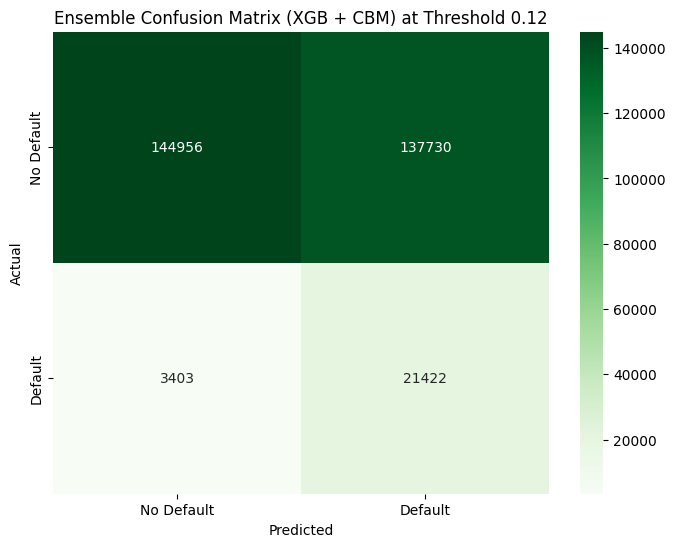

🚀 Final Ensemble AUC Score: 0.78561


In [ ]:
ensemble_oof_preds = (0.3 * XGB_oof_preds) + (0.7 * CBM_oof_preds)

threshold = 0.12
y_pred_binary = (ensemble_oof_preds > threshold).astype(int)

print("\n" + "="*30)
print(f"📊 Ensemble Classification Report (Threshold = {threshold}):")
print("="*30)
print(classification_report(y_train, y_pred_binary))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Ensemble Confusion Matrix (XGB + CBM) at Threshold {threshold}')
plt.show()

ensemble_auc = roc_auc_score(y_train, ensemble_oof_preds)
print(f"🚀 Final Ensemble AUC Score: {ensemble_auc:.5f}")

In [40]:
ensemble_oof_preds = (0.3 * XGB_oof_preds) + (0.7 * CBM_oof_preds)
print(f"📊 XGBoost OOF AUC: {roc_auc_score(y_train, XGB_oof_preds):.5f}")
print(f"📊 CatBoost OOF AUC: {roc_auc_score(y_train, CBM_oof_preds):.5f}")
print(f"🚀 Final Ensemble AUC (60/40): {roc_auc_score(y_train, ensemble_oof_preds):.5f}")

📊 XGBoost OOF AUC: 0.78349
📊 CatBoost OOF AUC: 0.78445
🚀 Final Ensemble AUC (60/40): 0.78561


In [39]:
final_stacking_test_preds = meta_model_ridge.predict(X_stack_test)

submission = pd.DataFrame({
    'SK_ID_CURR': test_ids, 
    'TARGET': final_stacking_test_preds
})
submission.to_csv('submission_kfold_engineered_features_with_optuna_stacked_XGB_CBM_LGBM_2_with_Ridge.csv', index=False)
print("🎯 Final K-Fold with engineered features submission saved!")

🎯 Final K-Fold with engineered features submission saved!


In [15]:
joblib.dump(XGB_full_pipeline, 'xgb_model_pipeline.pkl')

# حفظ موديل CatBoost
joblib.dump(CBM_full_pipeline, 'catboost_model_pipeline.pkl')

print("✅ Models saved successfully!")

✅ Models saved successfully!


🚀 Calculating Permutation Importance... This might take a minute.


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [22:57:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [22:57:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the devic

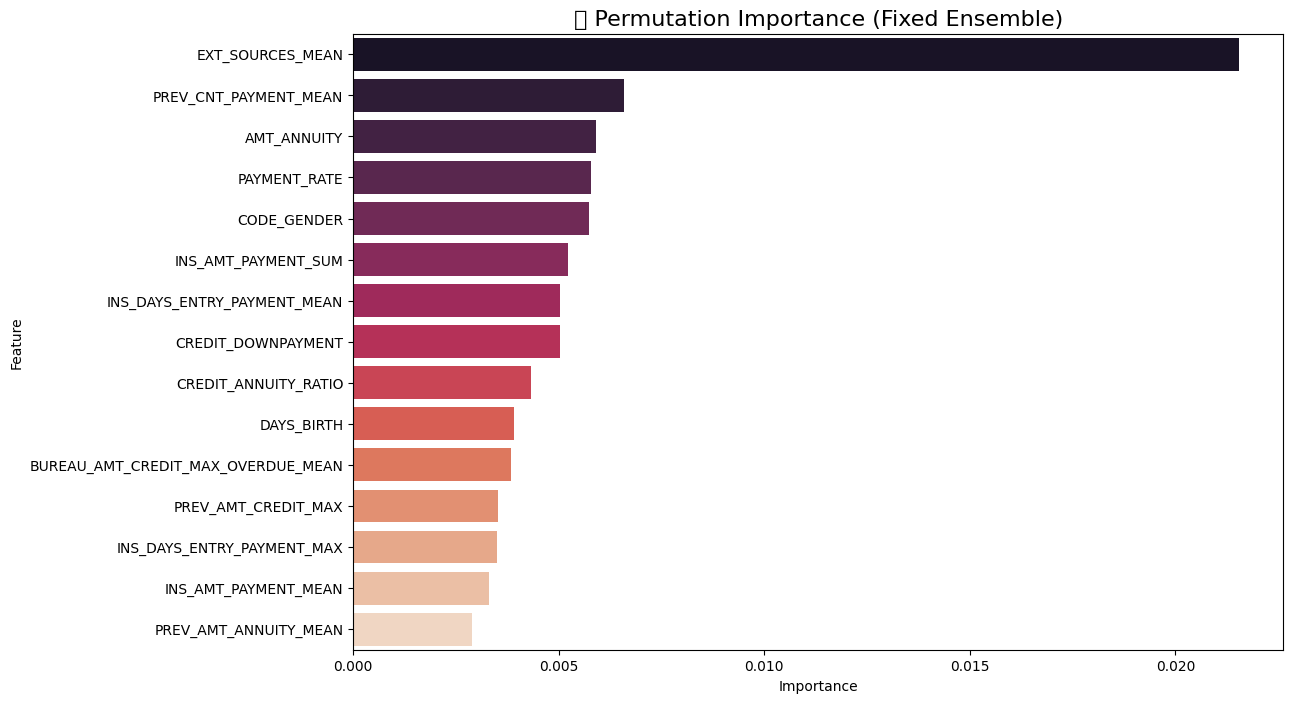

In [ ]:
def ensemble_predict_fixed(X):
    c_probs = CBM_full_pipeline.predict_proba(X)[:, 1]
    x_probs = XGB_full_pipeline.predict_proba(X)[:, 1]
    return (0.7 * c_probs) + (0.3 * x_probs)

X_sample = X_train.sample(5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

print("🚀 Calculating Permutation Importance... This might take a minute.")
results = permutation_importance(
    estimator=CBM_full_pipeline, 
    X=X_sample, 
    y=y_sample,
    scoring=lambda est, X, y: roc_auc_score(y, ensemble_predict_fixed(X)),
    n_repeats=3,
    random_state=42,
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'Feature': X_sample.columns,
    'Importance': results.importances_mean
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(data=perm_importance_df.head(15), x='Importance', y='Feature', palette='rocket')
plt.title('🔥 Permutation Importance (Fixed Ensemble)', fontsize=16)
plt.show()